In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer

#IMPORTAÇÃO NECESSARIAS PARA FUNCIONAMENTO DO CÓDIGO

In [ ]:
#Iniciar conexão com o google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#criar o spark com sessão
#Nesta parte inicia uma sessão com o spark onde ele cria um 'localhost'
spark = SparkSession.builder.appName("Modelo_Alunos").master("local[*]").getOrCreate()

In [ ]:
#Puxando dados do nosso arquivo do PI
df = spark.read.csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv", header=True, inferSchema=True)

In [ ]:
#Criando uma view temporaria para não precisarmos ficar puxando toda a hora o mesmo comando, nessa puxei os alunos
view = df.createOrReplaceTempView("alunos")

In [ ]:
#Nesta parte é onde fizemos a view, comandos de sql básicos, um select para puxar todos os dados da tabela alunas e o status de matriculado para verificar se está ativo, mostrando um total de 10 linhas
print("Consultando alunos com matricula ativa")
df_sql = spark.sql("SELECT * FROM alunos WHERE status = 'Matriculado' ")

df_sql.show(10)

Consultando alunos com matricula ativa
+--------+--------------------+--------------------+-------------------+-----------+-----+---------+-----+--------+--------------+---------------------+---------+--------------+--------+--------+-------------------+--------------------+-------+--------+------------+--------------------+--------------------+-------+--------+------------+--------------------+-----------------+-------+--------+------------+--------------------+-------------------+-------+--------+------------+--------------------+-------------------+-------+--------+------------+------------+
|aluno_id|          nome_aluno|         email_aluno|              curso|     status|turma|     sexo|idade|trabalha|renda_familiar|acompanhamento_medico|tem_filho|  estado_civil|semestre|bimestre|             aula_1|         professor_1|notas_1|faltas_1|desempenho_1|              aula_2|         professor_2|notas_2|faltas_2|desempenho_2|              aula_3|      professor_3|notas_3|faltas_3|dese

In [ ]:
#Colunas que selecionei para veriicar a situação do aluno para entendimento no final o motivo da evasão escolar
colunas_features = ['idade', 'renda_familiar', 'acompanhamento_medico', 'tem_filho']

In [ ]:
#prever a evasão
#Aqui estamos fazendo para prever o risco de evasão que esse aluno terá, utilizando os dados de cima para depois gerar a acuracia
df_clf = df.select(*colunas_features, "risco_evasao").dropna()
assember_clf = VectorAssembler(inputCols=colunas_features, outputCol="features")
df_clf = assember_clf.transform(df_clf).withColumnRenamed("risco_evasao", "label")


In [ ]:
#treina o modelo de árvore de decisão
#Treinando o modelo para ele verificar e nos mostrar a acuracia depois aqui ele toma as decisões para verificar se vai ser 0 ou 1
clf = DecisionTreeClassifier(labelCol="label", featuresCol="features")
clf_model = clf.fit(df_clf)


In [ ]:
#fazer previsões
#Fazer as decisões para as previsões necessarias
previsoes_clf = clf_model.transform(df_clf)



In [ ]:
#avaliar a acurácia do modelo
#aqui ele faz as previsões do modelo onde na linha abaixo retornara a porcentagem de acertos
avaliador_clf = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acuracia_clf = avaliador_clf.evaluate(previsoes_clf)
print("Acuracia de modelo da apresentação", acuracia_clf)

Acuracia de modelo da apresentação 0.924351804778851


In [ ]:
#mostrar exemplos de previsão do modelo
#nesta linha será mostrada a previsão dos dados, e mostra se a previsão foi correta ou não.
print("Exemplos de previsões do modelo:")
previsoes_clf.select("features", "label", "prediction").show(10, truncate=False)

Exemplos de previsões do modelo:
+------------------------+-----+----------+
|features                |label|prediction|
+------------------------+-----+----------+
|[28.0,2054.0,0.0,0.0]   |0    |0.0       |
|[36.0,5932.0,1.0,1.0]   |0    |0.0       |
|[3.0,6720.0,0.0,1.0]    |0    |0.0       |
|[19.0,4564.0,0.0,0.0]   |0    |0.0       |
|[36.0,4968.0,0.0,0.0]   |0    |0.0       |
|[24.0,2993.0,0.0,1.0]   |0    |0.0       |
|[130.0,9341.0,0.0,1.0]  |0    |0.0       |
|[27.0,923.0,0.0,0.0]    |0    |0.0       |
|[24.0,4303.0,1.0,0.0]   |0    |0.0       |
|[35.0,2088.0,0.0,1.0]   |0    |0.0       |
|[26.0,5412.0,1.0,0.0]   |0    |0.0       |
|[30.0,6005.0,1.0,0.0]   |0    |0.0       |
|[26.0,7215.0,1.0,1.0]   |0    |0.0       |
|[26.0,-230.0,0.0,1.0]   |0    |0.0       |
|[28.0,2389.0,1.0,0.0]   |0    |0.0       |
|[45.0,4572.0,1.0,0.0]   |0    |0.0       |
|[39.0,6343.0,1.0,1.0]   |1    |0.0       |
|[26.0,6843.0,1.0,1.0]   |0    |0.0       |
|[42.0,8591.0,0.0,1.0]   |0    |0.0       |

In [ ]:
#Esse atributo é um vetor indicando o peso de cada feature usada pelo modelo
importancia = clf_model.featureImportances
importancia_array = importancia.toArray()


Importancia das features: (4,[0,1,2,3],[0.3864107507157194,0.19682563191267322,0.18048720256749284,0.2362764148041145])


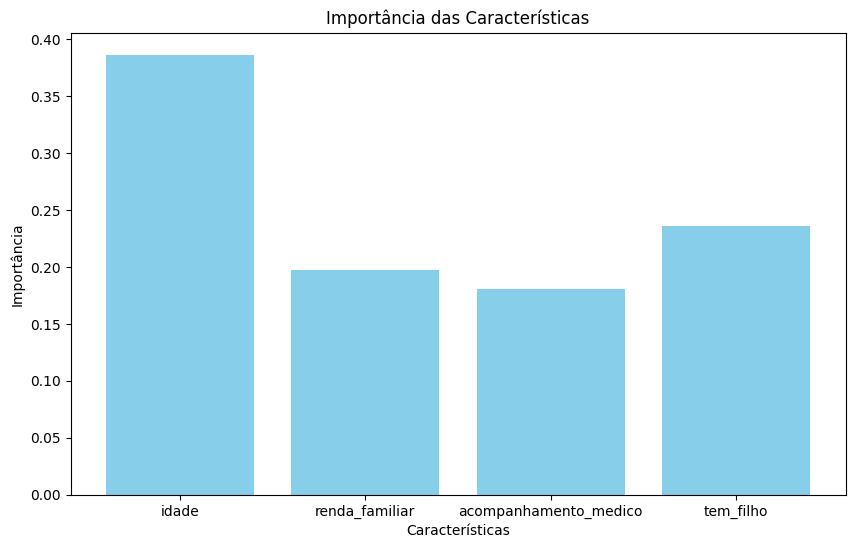

In [ ]:
#Criamos o gráfico para visualizar os dados das colunas anteriores
plt.figure(figsize=(10, 6))
plt.bar(colunas_features, importancia_array, color="skyblue")
plt.xlabel("Características")
plt.ylabel("Importância")
plt.title("Importância das Características")
plt.show()

In [ ]:
#realiza a divisão do DataFrame df_clf em dois subconjuntos para treinamento e teste
train_data, test_data = df_clf.randomSplit((0.8, 0.2), seed=42)

In [ ]:
#Treina com os dados de treino
clf_model = clf.fit(train_data)

In [ ]:
#Avalia com os dados de teste para esse código testa se o modelo está acertando bem nos dados que ele nunca viu.
previsoes_teste = clf_model.transform(test_data)
acuracia_teste = avaliador_clf.evaluate(previsoes_teste)
print(f"Acuracia nos dados de teste: ", acuracia_teste)

Acuracia nos dados de teste:  0.9201058201058201


In [ ]:
#Salva o modelo treinado para computação distruibuida para o meu drive
clf_model.save("/content/drive/MyDrive/modelo_treinador_spark")

In [ ]:
#Simulando a execução em outro local
#Carregando o modelo salvo

#o código carrega um modelo salvo, faz previsões e avalia a acuracia e mostra os dados atuais

from pyspark.ml.classification import DecisionTreeClassificationModel
modelo_carregado = DecisionTreeClassificationModel.load("/content/drive/MyDrive/modelo_treinador_spark")

# Fazer as previsões do modelo carregado
previsoes_carregado = modelo_carregado.transform(df_clf)

# Avaliar o modelo carregado
acuracia_carregado = avaliador_clf.evaluate(previsoes_carregado)
print("Acuracia do modelo carregado: ", acuracia_carregado)

Acuracia do modelo carregado:  0.9223182511438739


In [ ]:
#Encerrar servidor do spark
spark.stop()